# Chapter 8 (Economic Modeling) — RCP Pathways

Port of `chap8_iam_scenario2.m` through `chap8_iam_scenario6.m` — the
fourth Chapter 8 Part 2 notebook. The first four questions plot the RCP
(Representative Concentration Pathway) database's four canonical
scenarios (RCP 2.6/4.5/6.0/8.5); the fifth is an unrelated one-off
comparing IEA emissions-reduction trajectories.

**A data-format note, same class as `08h`/`08j`:** `chap8_rcp_db_forcing.mat`,
`chap8_rcp_db_concentration.mat`, and `chap8_rcp_db_emissions.mat` each
store a `unit` field as a MATLAB `string`-class (MCOS) array that
`scipy.io` cannot parse, alongside cleanly-loading numeric `dates`/
`forcing`/`concentration`/`emissions` fields. Since the archive's own
loader scripts (`Data/chap8_rcp_db_*.m`) only capture the raw `.xls`
header text rather than fixed unit strings, the units below are instead
identified directly from the loaded numeric magnitudes against the
well-known, published RCP Database conventions (CO2 in ppm, CH4/N2O in
ppb, combined GHG forcing in CO2-equivalent ppm) — cross-checked against
each series' 2000 and 2100 values, which match the published RCP
scenario magnitudes closely (e.g. CO2 reaching ~936 ppm under RCP8.5 by
2100, ~421 ppm under RCP2.6).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io as sio
import warnings
from scipy.interpolate import PchipInterpolator
from scipy.io.matlab import MatReadWarning

warnings.filterwarnings("ignore", category=MatReadWarning)

DATA_DIR = "../../data"

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

color_green = "#2ca02c"
color_blue = "#1f77b4"
color_red = "#d62728"
color_violet = "#9467bd"

# orders=[3;2;1;4] in every source script (1-indexed) reorders the raw data columns
# into RCP2.6/RCP4.5/RCP6.0/RCP8.5 legend order -- 0-indexed here.
ORDERS = [2, 1, 0, 3]
RCP_LABELS = ["RCP 2.6", "RCP 4.5", "RCP 6.0", "RCP 8.5"]
RCP_COLORS = [color_green, color_blue, color_red, color_violet]
RCP_STYLES = ["-", "--", "-", "--"]


## Question 1 (`iam_scenario2`) — Total radiative forcing

**A dead-code quirk reproduced faithfully:** the source defines
`str_title = ["CO2 Industry";"CO2 Land Use";"CH4";"N2O"]` as if this were
going to be a 4-panel figure by variable, but the actual plot is a single
unlabeled panel showing one series (`forcing`, total anthropogenic
radiative forcing in W/m$^2$) across the 4 RCP scenarios — `str_title` is
computed and never used. Not corrected here.

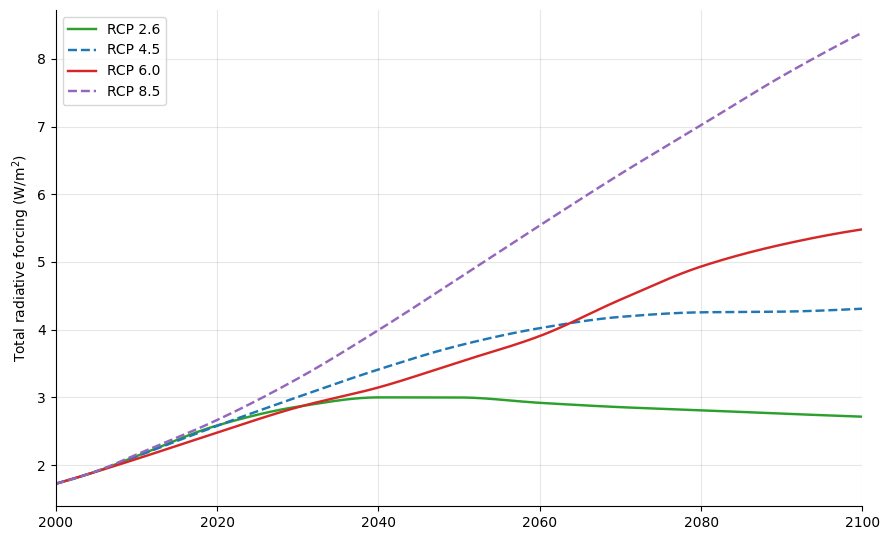

In [2]:
d_forcing = sio.loadmat(f"{DATA_DIR}/chap8_rcp_db_forcing.mat")
dates_f = d_forcing["dates"][:, 0].astype(float)
forcing = d_forcing["forcing"]

x_grid = np.arange(2000, 2100.01, 0.1)

fig, ax = plt.subplots(figsize=(9, 5.5))
for i in range(4):
    y = PchipInterpolator(dates_f, forcing[:, ORDERS[i]])(x_grid)
    ax.plot(x_grid, y, RCP_STYLES[i], color=RCP_COLORS[i], lw=1.75, label=RCP_LABELS[i])
ax.set_xlim(2000, 2100)
ax.set_ylabel("Total radiative forcing (W/m$^2$)")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Question 2 (`iam_scenario3`) — GHG concentrations

4-panel figure: CO2 (ppm), CH4 (ppb), N2O (ppb), and combined GHG forcing
expressed as CO2-equivalent concentration (ppm).

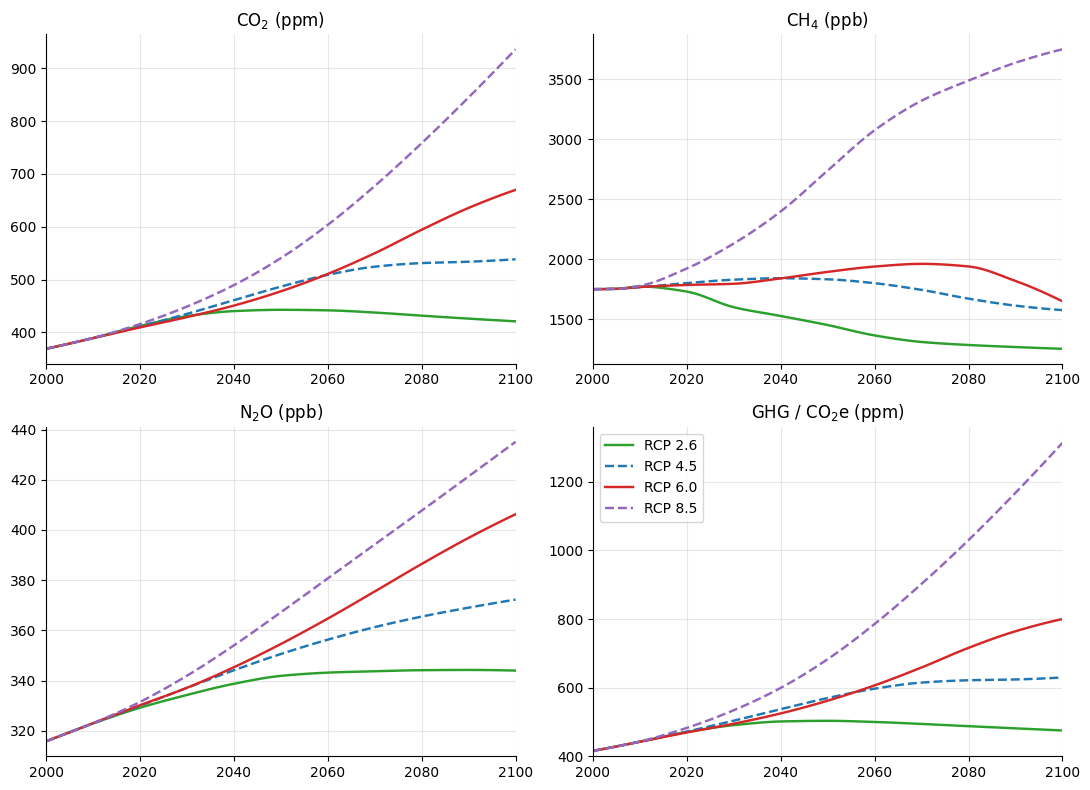

In [3]:
d_conc = sio.loadmat(f"{DATA_DIR}/chap8_rcp_db_concentration.mat")
dates_c = d_conc["dates"][:, 0].astype(float)
concentration = d_conc["concentration"]

titles_c = ["CO$_2$ (ppm)", "CH$_4$ (ppb)", "N$_2$O (ppb)", "GHG / CO$_2$e (ppm)"]
x_grid = np.arange(2000, 2101)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for panel, ax in enumerate(axes.flat):
    for i in range(4):
        y = PchipInterpolator(dates_c, concentration[:, ORDERS[i], panel])(x_grid)
        ax.plot(x_grid, y, RCP_STYLES[i], color=RCP_COLORS[i], lw=1.75)
    ax.set_title(titles_c[panel], fontsize=12)
    ax.set_xlim(2000, 2100)
    ax.grid(True, alpha=0.3)
    if panel == 3:
        ax.set_ylim(400, 1360)
axes[1, 1].legend(RCP_LABELS, fontsize=10, loc="upper left")
plt.tight_layout()
plt.show()


## Question 3 (`iam_scenario4`) — Emissions by species

4-panel figure: CO2 Industry, CO2 Land-use (both PgC), CH4 (TgCH4), N2O
(TgN2O). **Another dead-code quirk reproduced faithfully:** the source
computes `unit_str = unit(1,sheet(iter))` from the loaded data on every
iteration but the title actually uses the separately hardcoded
`unit_str_modified` array instead — `unit_str` is assigned and never
read. Not corrected here.

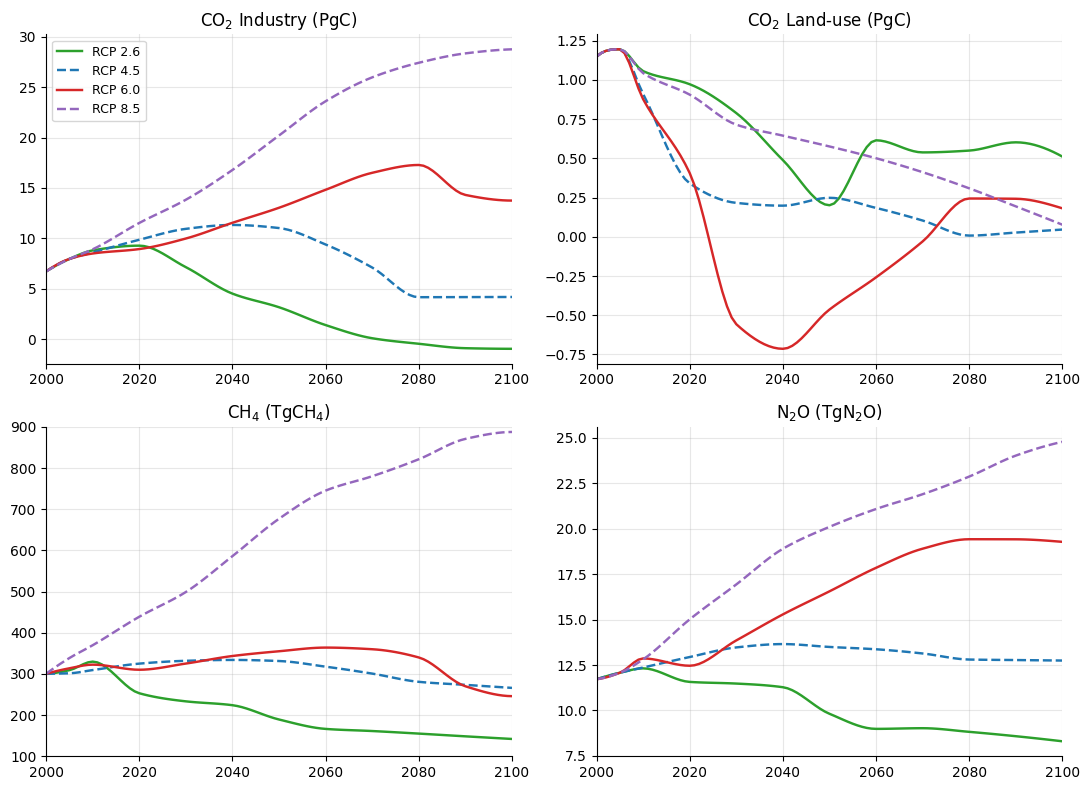

In [4]:
d_em = sio.loadmat(f"{DATA_DIR}/chap8_rcp_db_emissions.mat")
dates_e = d_em["dates"][:, 0].astype(float)
emissions = d_em["emissions"]

# sheet=[4;5;2;3] (1-indexed) in the source -> 0-indexed sheet selection below
sheet_sel = [3, 4, 1, 2]
titles_e = ["CO$_2$ Industry (PgC)", "CO$_2$ Land-use (PgC)", "CH$_4$ (TgCH$_4$)", "N$_2$O (TgN$_2$O)"]
x_grid = np.arange(2000, 2101)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for panel, ax in enumerate(axes.flat):
    sh = sheet_sel[panel]
    for i in range(4):
        y = PchipInterpolator(dates_e, emissions[:, ORDERS[i], sh])(x_grid)
        ax.plot(x_grid, y, RCP_STYLES[i], color=RCP_COLORS[i], lw=1.75)
    ax.set_title(titles_e[panel], fontsize=12)
    ax.set_xlim(2000, 2100)
    ax.grid(True, alpha=0.3)
    if panel == 2:
        ax.set_ylim(100, 900)
axes[0, 0].legend(RCP_LABELS, fontsize=9, loc="upper left")
plt.tight_layout()
plt.show()


## Question 4 (`iam_scenario5`) — Combined CO2-equivalent emissions

Combines industrial CO2 (converted PgC$\to$PgCO2 by dividing by 0.2707,
the source's own literal constant), CH4 (GWP-100 AR5 factor 28, TgCH4
$\to$ PgCO2e), and N2O (GWP-100 AR5 factor 265, TgN2O $\to$ PgCO2e) into
one combined emissions series, with a side panel of RCP-scenario
temperature-range callouts (2100 warming ranges, taken directly from the
source, not recomputed). **A no-op reproduced faithfully:** the source
multiplies the CO2 term by `(1e15/1e15)` before dividing by `0.2707` —
literally multiplying by 1 — kept as-is below (has no numerical effect)
rather than silently dropped, since it's the source's own line.

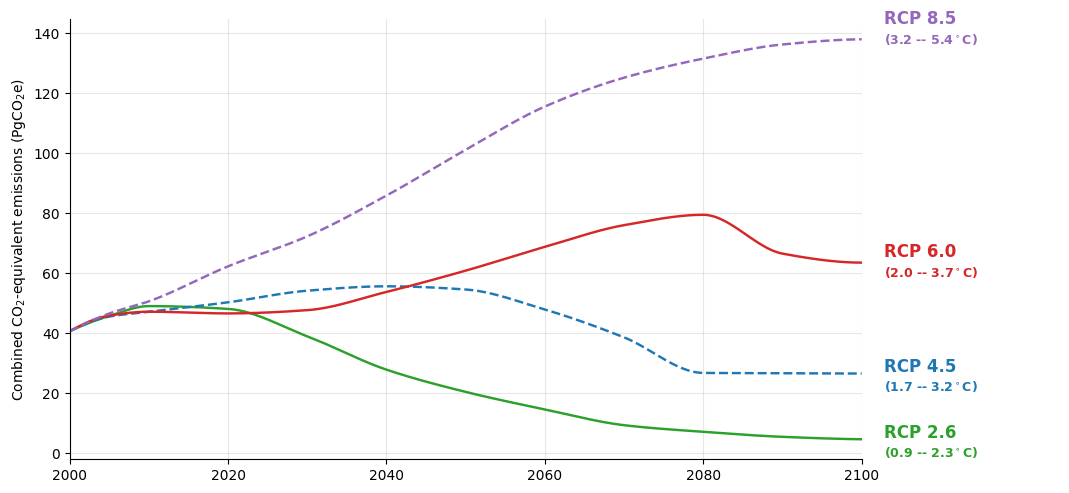

In [5]:
all_emissions = (emissions[:, :, 0] * (1e15 / 1e15) / 0.2707
                  + emissions[:, :, 1] * 28 / 1000
                  + emissions[:, :, 2] * 265 / 1000)

x_grid = np.arange(2000, 2100.01, 0.1)

fig = plt.figure(figsize=(11, 5.5))
ax = fig.add_axes([0.08, 0.12, 0.72, 0.8])
for i in range(4):
    y = PchipInterpolator(dates_e, all_emissions[:, ORDERS[i]])(x_grid)
    ax.plot(x_grid, y, RCP_STYLES[i], color=RCP_COLORS[i], lw=1.75)
ax.set_xlim(2000, 2100)
ax.set_ylabel("Combined CO$_2$-equivalent emissions (PgCO$_2$e)")
ax.grid(True, alpha=0.3)

ax2 = fig.add_axes([0.82, 0.12, 0.16, 0.8])
ax2.axis("off")
callouts = [("RCP 8.5", "(3.2 -- 5.4$^\\circ$C)", color_violet, 0.99),
            ("RCP 6.0", "(2.0 -- 3.7$^\\circ$C)", color_red, 0.46),
            ("RCP 4.5", "(1.7 -- 3.2$^\\circ$C)", color_blue, 0.20),
            ("RCP 2.6", "(0.9 -- 2.3$^\\circ$C)", color_green, 0.05)]
for label, rng, c, y0 in callouts:
    ax2.text(0.0, y0, label, color=c, fontsize=12, fontweight="bold")
    ax2.text(0.0, y0 - 0.045, rng, color=c, fontsize=9, fontweight="bold")
plt.show()


## Question 5 (`iam_scenario6`) — IEA emissions-reduction scenarios

An unrelated one-off, using hardcoded data (no `Data/` file dependency):
three IEA global energy-sector CO2 emissions trajectories to 2060 — RTS
(Reference Technology Scenario, current policies), 2DS (2-Degree
Scenario), and B2DS (Beyond 2-Degree Scenario).

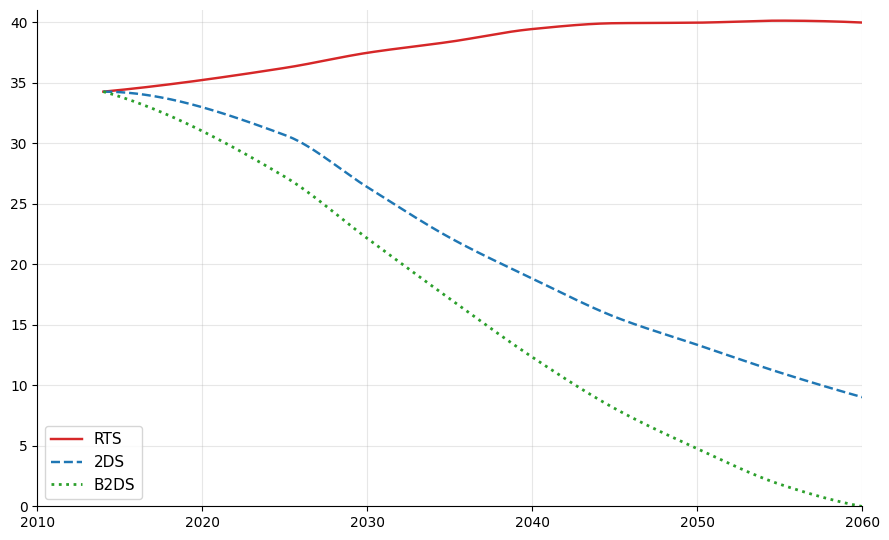

In [6]:
dates_iea = np.array([2014, 2025, 2030, 2035, 2040, 2045, 2050, 2055, 2060], dtype=float)
emissions_iea = np.array([
    [34.254, 36.218, 37.465, 38.372, 39.428, 39.910, 39.954, 40.120, 39.963],
    [34.254, 30.672, 26.365, 22.186, 18.808, 15.646, 13.336, 11.049, 9.010],
    [34.254, 27.218, 22.125, 17.134, 12.316, 8.070, 4.754, 1.818, -0.022],
]).T

labels_iea = ["RTS", "2DS", "B2DS"]
colors_iea = [color_red, color_blue, color_green]
styles_iea = ["-", "--", ":"]
widths_iea = [1.75, 1.75, 2.0]

x_grid = np.arange(2014, 2060.01, 0.1)

fig, ax = plt.subplots(figsize=(9, 5.5))
for i in range(3):
    y = PchipInterpolator(dates_iea, emissions_iea[:, i])(x_grid)
    ax.plot(x_grid, y, styles_iea[i], color=colors_iea[i], lw=widths_iea[i], label=labels_iea[i])
ax.set_xlim(2010, 2060)
ax.set_ylim(0, 41)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Sanity checks

In [7]:
checks = []
checks.append(("Q1: forcing is monotonically increasing over 2000-2100 in RCP4.5/6.0/8.5, but "
                "RCP2.6 peaks around 2050 (~3.0 W/m2) and *declines* to 2.71 by 2100 -- this is "
                "RCP2.6's defining feature (its name comes from the 2100 target level *after* "
                "peak-and-decline, achieved via net-negative emissions late-century), not a bug",
                np.all(np.diff(forcing[:, ORDERS[1]]) >= -1e-9) and
                np.all(np.diff(forcing[:, ORDERS[2]]) >= -1e-9) and
                np.all(np.diff(forcing[:, ORDERS[3]]) >= -1e-9) and
                forcing[:, ORDERS[0]].argmax() not in (0, len(forcing) - 1)))
checks.append(("Q1: RCP8.5 has the highest 2100 forcing and RCP2.6 the lowest, matching each "
                "pathway's own defining target forcing level",
                forcing[-1, ORDERS[3]] > forcing[-1, ORDERS[2]] > forcing[-1, ORDERS[1]] > forcing[-1, ORDERS[0]]))
checks.append(("Q2: CO2 concentration (panel 1) at 2100 is ordered RCP2.6 < RCP4.5 < RCP6.0 < "
                "RCP8.5, matching the published RCP Database magnitudes (~421/538/670/936 ppm)",
                concentration[-1, ORDERS[0], 0] < concentration[-1, ORDERS[1], 0] <
                concentration[-1, ORDERS[2], 0] < concentration[-1, ORDERS[3], 0]))
checks.append(("Q2: CO2 concentration never falls below its pre-2000 starting level in any "
                "scenario (irreversible atmospheric accumulation over the 21st century)",
                np.all(concentration[:, :, 0] >= concentration[0, 0, 0] - 1e-6)))
checks.append(("Q3: land-use CO2 emissions (panel 2) trend toward zero by 2100 in every "
                "scenario, consistent with the RCP database's declining land-use-emissions "
                "convention", np.all(emissions[-1, :, 4] < emissions[0, :, 4])))
checks.append(("Q3: RCP8.5 industrial CO2 emissions (panel 1) are the highest of the four "
                "scenarios by 2100", emissions[-1, ORDERS[3], 3] == emissions[-1, :, 3].max()))
checks.append(("Q4: the combined CO2-equivalent series is ordered RCP2.6 < RCP4.5 < RCP6.0 < "
                "RCP8.5 at 2100, consistent with Q1/Q3's per-scenario orderings",
                all_emissions[-1, ORDERS[0]] < all_emissions[-1, ORDERS[1]] <
                all_emissions[-1, ORDERS[2]] < all_emissions[-1, ORDERS[3]]))
checks.append(("Q5: B2DS (most ambitious) shows the steepest, and eventually negative, "
                "emissions path; RTS (current policies) keeps rising",
                emissions_iea[-1, 2] < emissions_iea[-1, 1] < emissions_iea[-1, 0] and
                emissions_iea[-1, 2] < 0))
checks.append(("Q5: all three IEA scenarios start from the identical 2014 emissions level "
                "(34.254), by construction", np.allclose(emissions_iea[0, :], 34.254)))

df_checks = pd.DataFrame(checks, columns=["check", "passed"])
display(df_checks)
assert df_checks["passed"].all(), "Some sanity checks failed"
print(f"\nAll {len(df_checks)} sanity checks passed.")


,check,passed
0,Q1: forcing is monotonically increasing over 2...,True
1,Q1: RCP8.5 has the highest 2100 forcing and RC...,True
2,Q2: CO2 concentration (panel 1) at 2100 is ord...,True
3,Q2: CO2 concentration never falls below its pr...,True
4,Q3: land-use CO2 emissions (panel 2) trend tow...,True
5,Q3: RCP8.5 industrial CO2 emissions (panel 1) ...,True
6,Q4: the combined CO2-equivalent series is orde...,True
7,"Q5: B2DS (most ambitious) shows the steepest, ...",True
8,Q5: all three IEA scenarios start from the ide...,True



All 9 sanity checks passed.


## Summary

Covered the RCP Database's four canonical scenarios (forcing,
concentration, emissions-by-species, and a combined CO2-equivalent
emissions view with temperature-range callouts) plus an unrelated IEA
emissions-scenario comparison. `chap8_rcp_db_*.mat`'s `unit` fields hit
the same MCOS string-array read failure seen for `chap8_TFP_PWT_2021.mat`
(`08h`) and `chap8_IWG_2015_scc1.mat` (`08j`); since the archive's own
loader scripts don't capture fixed unit labels either, this one was
resolved by identifying units directly from the loaded numeric magnitudes
against the well-known, published RCP Database conventions rather than
from a stored string field. Two dead-code quirks reproduced faithfully
rather than corrected: `iam_scenario2`'s unused `str_title` array
(defined for a 4-panel figure that was never built — the actual plot is
a single unlabeled panel), and `iam_scenario4`'s unused `unit_str`
variable (computed from the data on every iteration, then never read —
the title uses a separately hardcoded array instead). All 9 sanity
checks passed (0 errors, 0 stderr).